In [1]:
from autstr.arithmetic import VariableETerm as Var
from time import time
x = Var('x')

# Algorithmic Design with Infinite Sets: The Sieve of Eratosthenes
AutStr enables novel algorithm design using infinite sets as first-class citizens. This implementation of the Sieve of Eratosthenes maintains the infinite candidate prime set symbolically:

[2]
computing next prime took: 0.012612581253051758 seconds
[2, 3]
computing next prime took: 0.04053163528442383 seconds
[2, 3, 5]
computing next prime took: 0.09251642227172852 seconds
Primes found: [2, 3, 5]
Remaining infinite set:


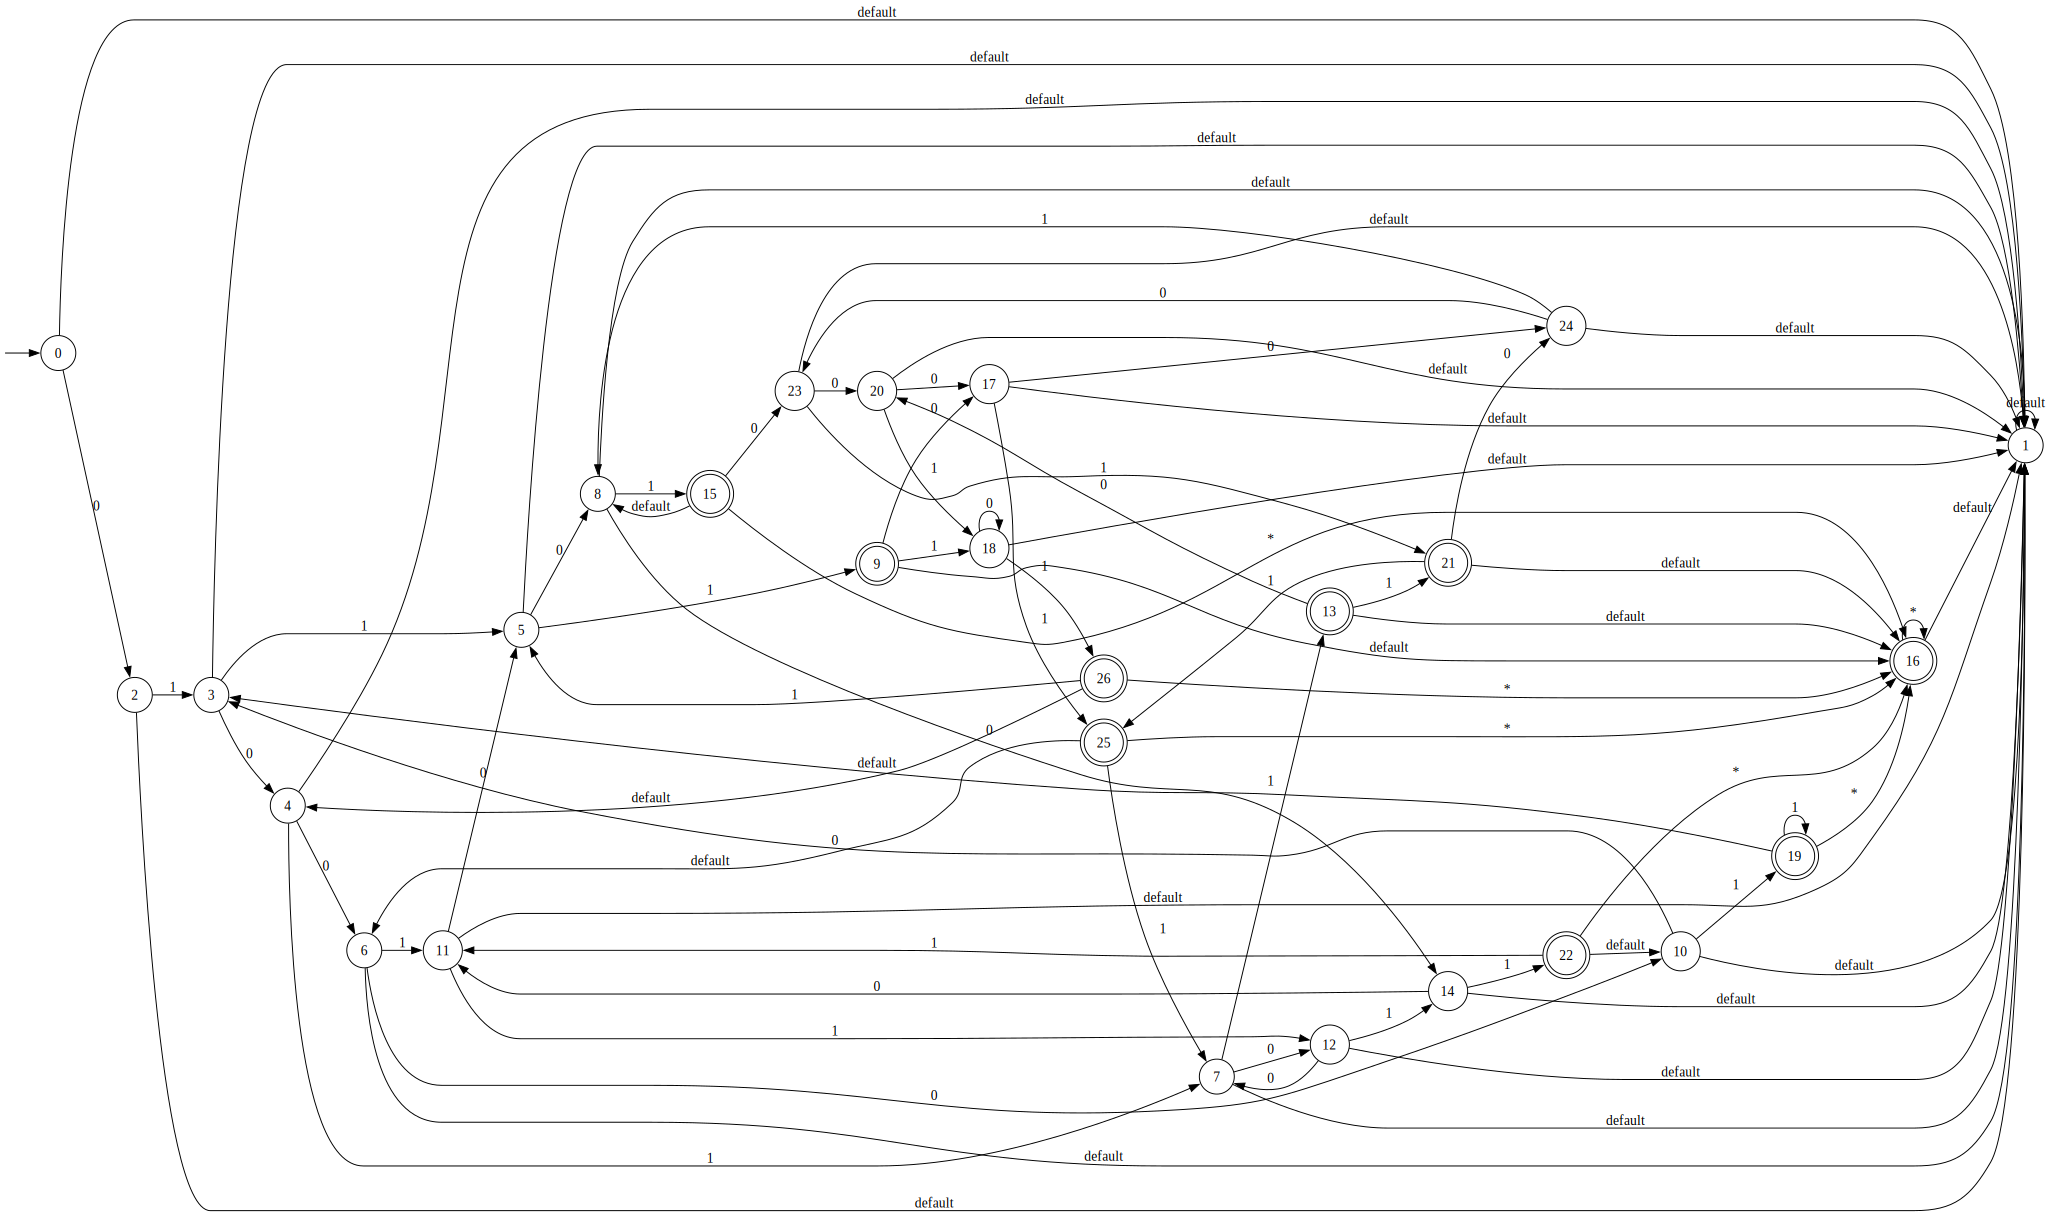

In [2]:
def infinite_sieve(steps):
    """Sieve of Eratosthenes over infinite integers"""
    x = Var('x')
    candidates = (x.gt(1))  # Initial infinite set: {2,3,4,...}
    primes = []
    
    for _ in range(steps):
        # Find smallest candidate (symbolic operation)
        start = time()
        for p in candidates: # Elements are listed in ascending order (absolute values) 
            primes.append(p[0])
            print(primes)
            break
        end = time()
        print(f"computing next prime took: {end - start} seconds")
        
        # Remove multiples: candidates = candidates \ {k·p | k>1}
        p = primes[-1]
        y = Var("y")
        multiples = (x.eq(p * y)).drop("y")
        candidates = candidates & ~multiples 
        
    return primes, candidates

# Execute first 5 sieving steps
primes, remaining = infinite_sieve(steps=3)
print(f"Primes found: {primes}")  # [2,3,5,7,11]
print(f"Remaining infinite set:") 
remaining.evaluate().show_diagram()

# Integer Linear Equation Systems
As we have seen, working with infinite structures is for sure compute intense. This is due to the fact that we can define (and in principle solve) extremly complext problems within our formalism. Solving linear equation systems with integer constraints is one such problem. In contrast to their continuous counterparts, integer linear equation systems are known to bw NP hard to solve.  

With the Arithmetic package, we can easily define and solve such systems.

In [3]:
# Define variables
x,y, z = Var("x"), Var("y"), Var("z")

# Solvable

In [4]:
%%time
eq1 = (x + y).eq(6) 
eq2 = (y + z).eq(12) 
eq3 = (x + z).eq(10) 
eqn_sys = eq1 & eq2 & eq3

for s in eqn_sys:
    print(s)

(2, 4, 8)
CPU times: user 325 ms, sys: 5.98 ms, total: 331 ms
Wall time: 331 ms


## Unsolvable

In [5]:
%%time

eq1 = (3 * y + 5 * z).eq(1) 
eq2 = (x + y).eq(5) 
eq3 = (10*z + x).eq(17) 
eqn_sys = eq1 & eq2 & eq3

eqn_sys.isempty()

CPU times: user 1.69 s, sys: 28.7 ms, total: 1.71 s
Wall time: 1.72 s


True